In [ ]:
!pip install timm scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.9 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Paths
train_dir = '/content/drive/MyDrive/Hands40/train'
val_dir   = '/content/drive/MyDrive/Hands40/val'
test_dir  = '/content/drive/MyDrive/Hands40/test'

# Parameters
num_classes = 40
batch_size = 32
image_size = 224
epochs = 50
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
# Datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Label smoothing loss
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1):
        super().__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.log_softmax = nn.LogSoftmax(dim=-1)

    def forward(self, x, target):
        logprobs = self.log_softmax(x)
        with torch.no_grad():
            true_dist = torch.zeros_like(logprobs)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * logprobs, dim=-1))


In [ ]:
# Model
model = timm.create_model('mobilenetv2_100', pretrained=True, num_classes=num_classes)
model.to(device)

criterion = LabelSmoothingLoss(classes=num_classes, smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

In [ ]:
# Train & evaluate functions
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += out.argmax(1).eq(y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += out.argmax(1).eq(y).sum().item()
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
            total += y.size(0)
    return total_loss / total, correct / total, preds, labels

In [ ]:
# Training loop
train_accs, val_accs = [], []
train_losses, val_losses = [], []

for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}")


Epoch 1/50 - Train Acc: 0.0416, Val Acc: 0.0566, Val Loss: 3.8422
Epoch 2/50 - Train Acc: 0.1430, Val Acc: 0.1321, Val Loss: 3.4780
Epoch 3/50 - Train Acc: 0.2225, Val Acc: 0.1824, Val Loss: 3.2649
Epoch 4/50 - Train Acc: 0.2518, Val Acc: 0.2327, Val Loss: 3.0325
Epoch 5/50 - Train Acc: 0.3851, Val Acc: 0.2956, Val Loss: 2.7958
Epoch 6/50 - Train Acc: 0.4487, Val Acc: 0.4088, Val Loss: 2.6477
Epoch 7/50 - Train Acc: 0.5257, Val Acc: 0.4403, Val Loss: 2.4175
Epoch 8/50 - Train Acc: 0.6149, Val Acc: 0.5157, Val Loss: 2.2323
Epoch 9/50 - Train Acc: 0.6112, Val Acc: 0.5723, Val Loss: 2.0812
Epoch 10/50 - Train Acc: 0.6430, Val Acc: 0.5975, Val Loss: 1.9371
Epoch 11/50 - Train Acc: 0.6675, Val Acc: 0.6478, Val Loss: 1.8656
Epoch 12/50 - Train Acc: 0.7139, Val Acc: 0.6478, Val Loss: 1.8011
Epoch 13/50 - Train Acc: 0.7567, Val Acc: 0.7296, Val Loss: 1.6711
Epoch 14/50 - Train Acc: 0.7641, Val Acc: 0.7421, Val Loss: 1.6174
Epoch 15/50 - Train Acc: 0.7738, Val Acc: 0.7421, Val Loss: 1.5655
Epoc


✅ Test Accuracy: 0.9045, Test Loss: 1.1643


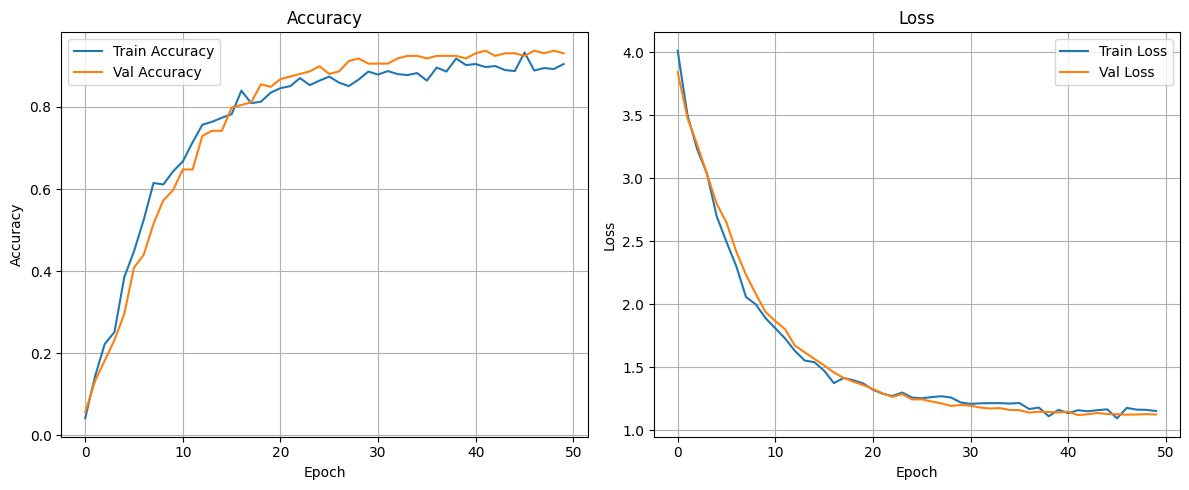

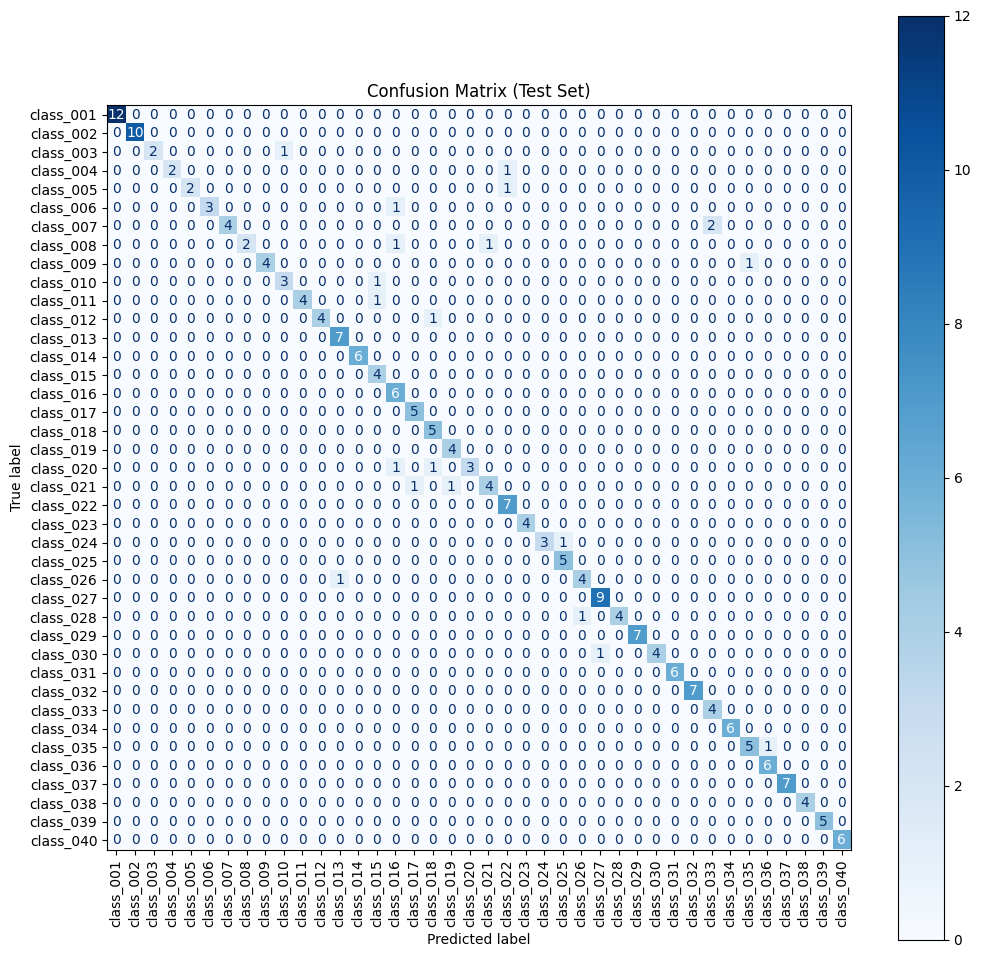

In [ ]:
# Final test
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader)
print(f"\n✅ Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Plot accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.show()


In [ ]:
torch.save(model.state_dict(), "mobilenetv2_hands40.pth")